# DBNets2.0. Tutorial: application to an actual observation
In this jupyter notebook the tool is applied to MWC480 (data from the ALMA archive)

1. Install DBNets following the instructions provided on the github repo.

2. Import the DBNets2 library and initialize the models. Provide the paths of the trained CNN and Normalizing Flows.

In [4]:
from DBNets import DBNets
dbnets = DBNets.DBNets2(path_cnn='../test_CNN/models/only4para2_long/', path_nf='../SBI_and_Validation/trained/withres/')

3. Collect the data needed on the protoplanetary disc under exam
    - fits file with the continuum observation in ALMA band 6 or 7
    - centre of the disc in pixel coordinates
    - inclination
    - position angle
    - planet position (as an angle or as distance + physical separation)

![definition of inclination and position angle](inclandpa.png)

In [11]:
file_name = 'mwc480.fits'
centre = (1024, 1026)
inclination = 36
pa = 58
distance = 161
rp = 73
res_ba_arcsec = 0.15

#define the image resolution in the same code units used in the code
res_sigma = res_ba_arcsec/2.35*distance/rp

(-0.5, 2047.5, 2047.5, -0.5)

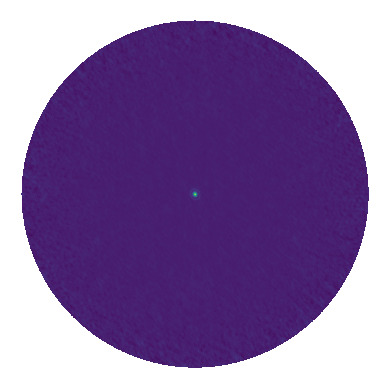

In [14]:
#you can check the image
from astropy.io import fits

hdu = fits.open(file_name)[0]
plt.imshow(hdu.data[0,0])
plt.axis('off')

4. use DBNets.preproc module to open and preprocess the fits file. This function opens the fits file, rescales and deprojects the disc to make the observation geometrically homogeneous with the synthetic observations used to train the ensemble. The following picture shows the data before and after.

![preprocessing](preprocess.png)

In [7]:
from DBNets import preproc as pp
deproj_image = pp.deproject_image(file_name, distance, inclination, pa, centre, rp)

this is the image obtained

(-0.5, 127.5, 127.5, -0.5)

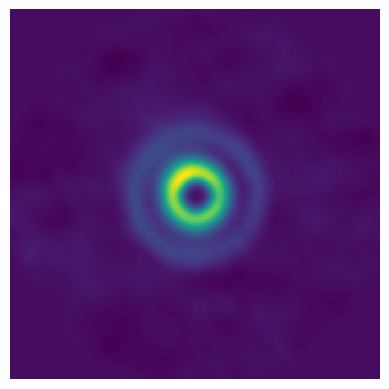

In [8]:
import matplotlib.pyplot as plt
plt.imshow(deproj_image)
plt.axis('off')

5. run the inference sampling N points from the inferred posterior

In [31]:
samples = dbnets(deproj_image, [res_sigma], nsamples=5000, get_rej_metric=False)

Drawing 990 posterior samples:   0%|          | 0/990 [00:00<?, ?it/s]

Drawing 958 posterior samples:   0%|          | 0/958 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1033 posterior samples:   0%|          | 0/1033 [00:00<?, ?it/s]

Drawing 1019 posterior samples:   0%|          | 0/1019 [00:00<?, ?it/s]

The method returns `nsamples` samples from the inferred posterior. The values are normalized, with the dbnets2.0 method, between -1 and 1. You can use the function `utils.to_real` to convert these to actual values.

In [32]:
from DBNets import utils
real_samp = utils.to_real(samples)

in both cases, samples have shape (ninputs, nsamples, 4) where the last dimension corresponds to the 4 inferred properties in the following order: Alpha, AspectRatio, Stokes, PlanetMass.

In [35]:
samples.shape

(1, 5000, 4)

You can plot these results, for example, using the function `utils.plot_corner`. Note that this function takes the normalized samples as input.

In [36]:
utils.plot_corner?

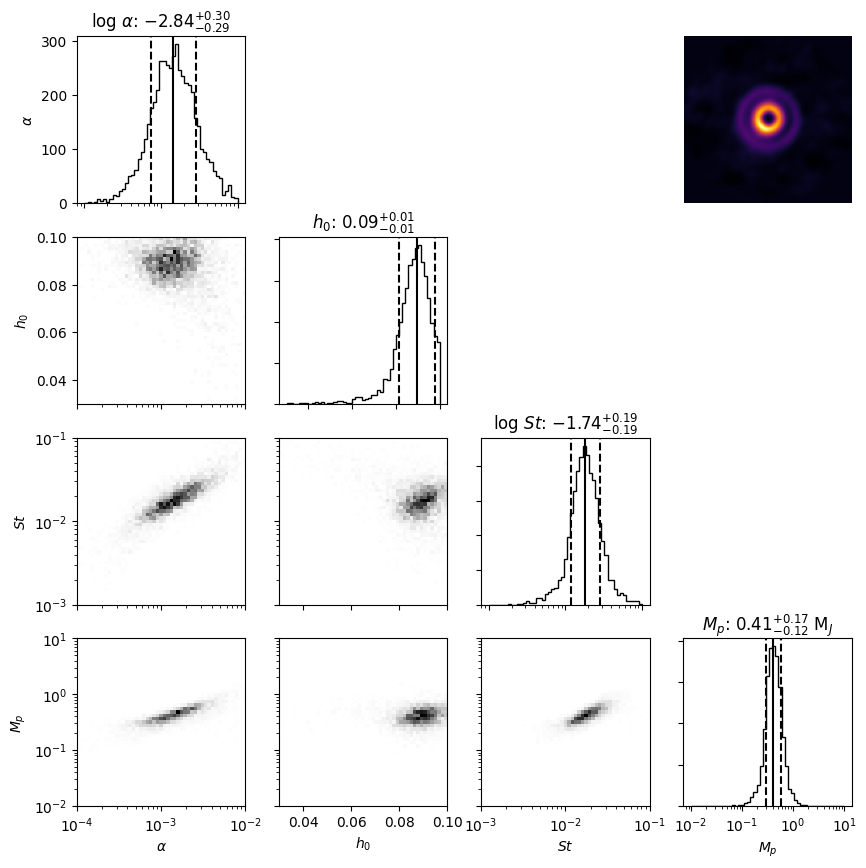

In [41]:
utils.plot_corner(samples,'mwc480', 1., 'corner.pdf', image = deproj_image)